In [2]:
!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.893 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools          84.0.0

In [3]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.912 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge


In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10,20,30,40,50],
    'B': [5,15,25,35,45]})
print(data)
scaler = MinMaxScaler()
normalized_data=scaler.fit_transform(data)

normalized_df=pd.DataFrame(normalized_data, columns = data.columns)
print("normalized (Min-Max Scaling):")
print(normalized_df)


    A   B
0  10   5
1  20  15
2  30  25
3  40  35
4  50  45
normalized (Min-Max Scaling):
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardized_data=scaler.fit_transform(data)
standardized_df = pd.DataFrame(standardized_data, columns = data.columns)
print("\nStandardized Data:")
print(standardized_df)


Standardized Data:
          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [8]:
df=pd.DataFrame({'Color': ['Red', 'Blue' , 'Green' , 'Red', 'Blue']})
one_hot = pd.get_dummies(df, columns=['Color'])
print("\nOne-Hot Encoding:")
print(one_hot)


One-Hot Encoding:
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [4]:
!pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
tips= sns.load_dataset("tips")
print("Original Data (first 5 rows):")
print(tips.head())
numeric_cols=tips.select_dtypes(include=['float64','int64']).columns
scaler_minmax=MinMaxScaler()
tips_normalized = tips.copy()
tips_normalized[numeric_cols] = scaler_minmax.fit_transform(tips[numeric_cols])
print("\nNormalized Data (first 5 rows):")
print(tips_normalized.head())
#2.Standardization (z-score)
scaler_standard=StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols] = scaler_standard.fit_transform(tips[numeric_cols])
print("\nStandardized Data (first 5 rows):")
print(tips_standardized.head())

#3. Encoding categorical Variables
tips_onehot = pd.get_dummies(tips, columns=['sex','smoker','day','time'])
print("\nOne-Hot Encoded Data (first 5 rows):")
print(tips_onehot.head())

Original Data (first 5 rows):
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Normalized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6

Standardized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun 

In [18]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
tips=sns.load_dataset("tips")
numeric_cols = tips.select_dtypes(include=['float64' , 'int64'])

scaler=StandardScaler()
scaled_data=scaler.fit_transform(numeric_cols)

pca=PCA(n_components=2)
pca_result=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(data=pca_result,columns=['PC1','PC2'])

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())

Explained variance ratio: [0.72627656 0.1730423 ]

PCA Result (first 5 rows):
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


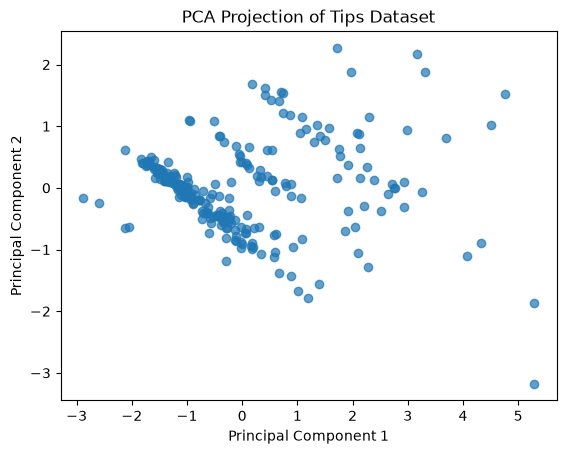

In [19]:
import matplotlib.pyplot as plt

plt.scatter(pca_df['PC1'],pca_df['PC2'],alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Tips Dataset')
plt.show()

In [20]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
iris=pd.read_csv("Iris.csv")
numeric_cols = iris.select_dtypes(include=['float64' , 'int64'])

scaler=StandardScaler()
scaled_data=scaler.fit_transform(numeric_cols)

pca=PCA(n_components=2)
pca_result=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(data=pca_result,columns=['PC1','PC2'])

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())

Explained variance ratio: [0.7470533  0.18435257]

PCA Result (first 5 rows):
        PC1       PC2
0 -2.816339  0.506051
1 -2.645527 -0.651799
2 -2.879481 -0.321036
3 -2.810934 -0.577363
4 -2.879884  0.670468


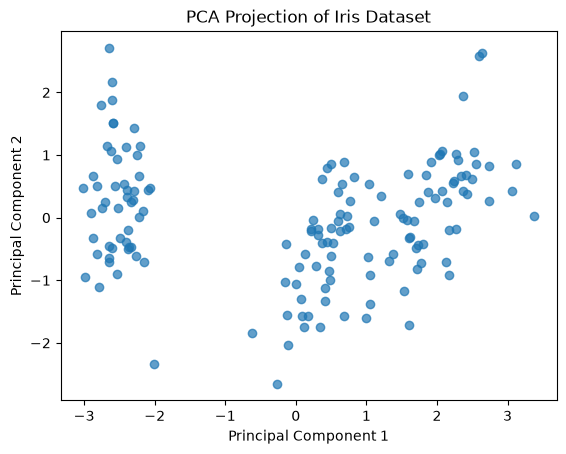

In [22]:
import matplotlib.pyplot as plt

plt.scatter(pca_df['PC1'],pca_df['PC2'],alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Iris Dataset')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

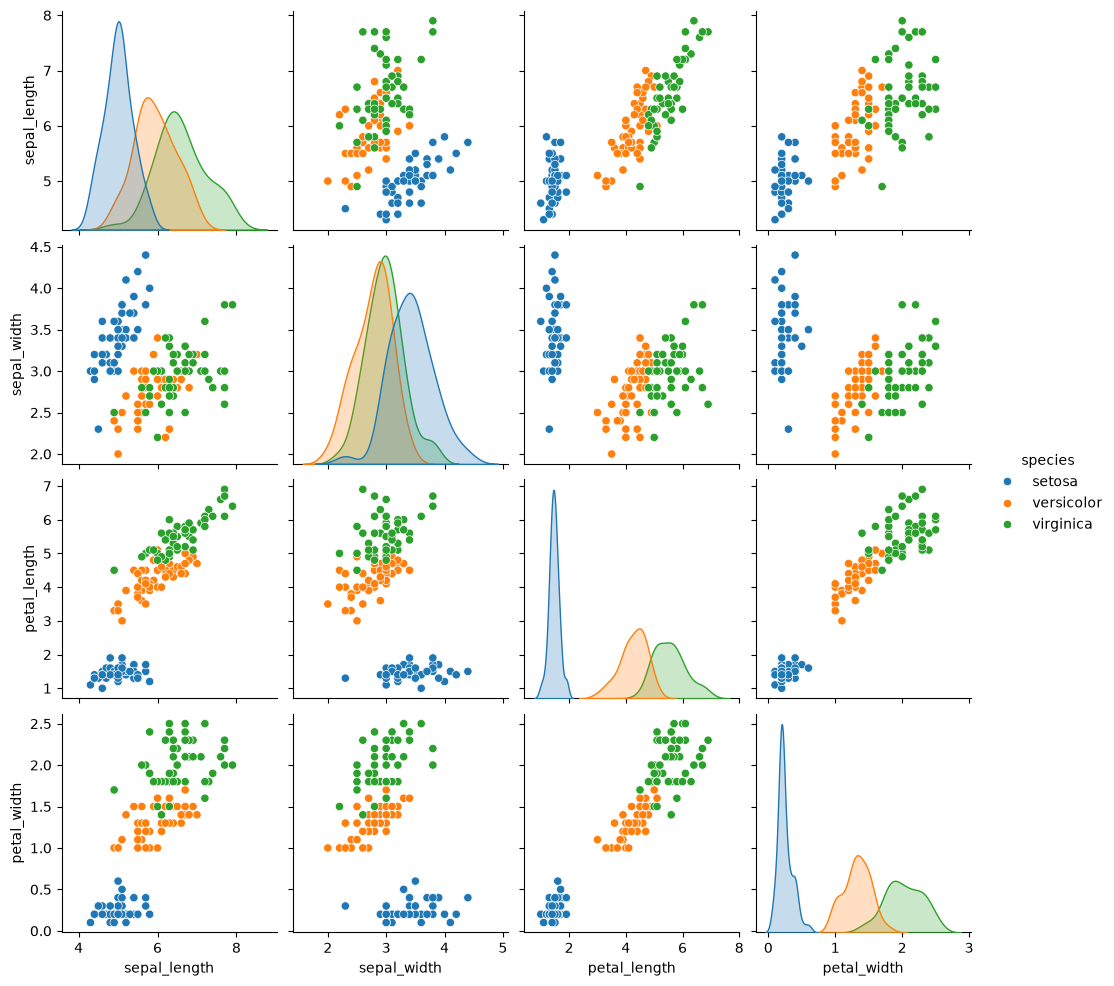

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
data=sns.load_dataset("iris")
sns.pairplot(data,hue='species')
plt.show

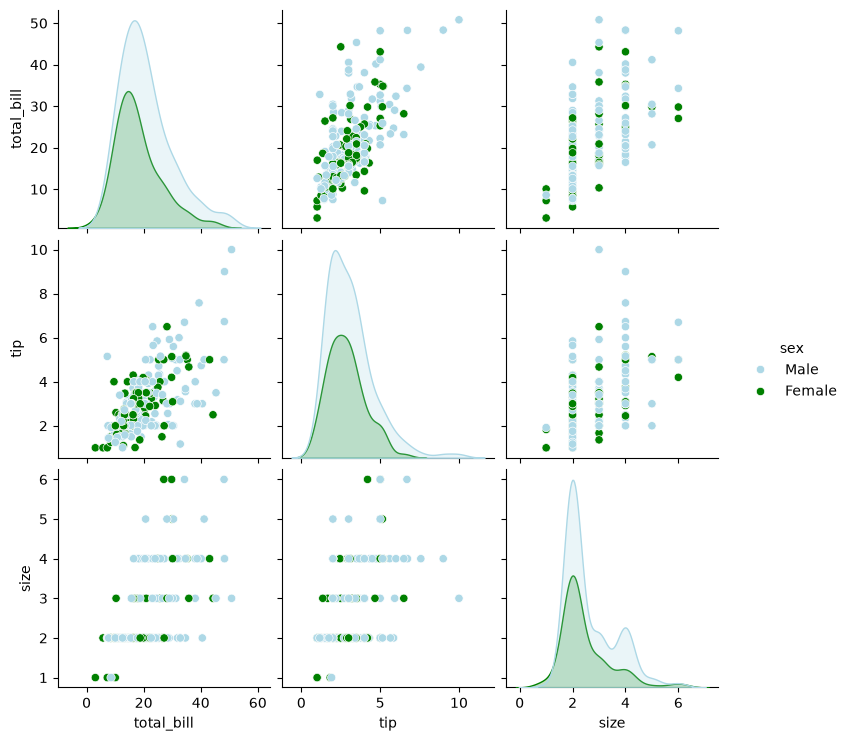

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
```
c_p={'Male':'lightblue','Female':'green'}
sns.pairplot(data,hue='sex',palette=c_p)
plt.show()

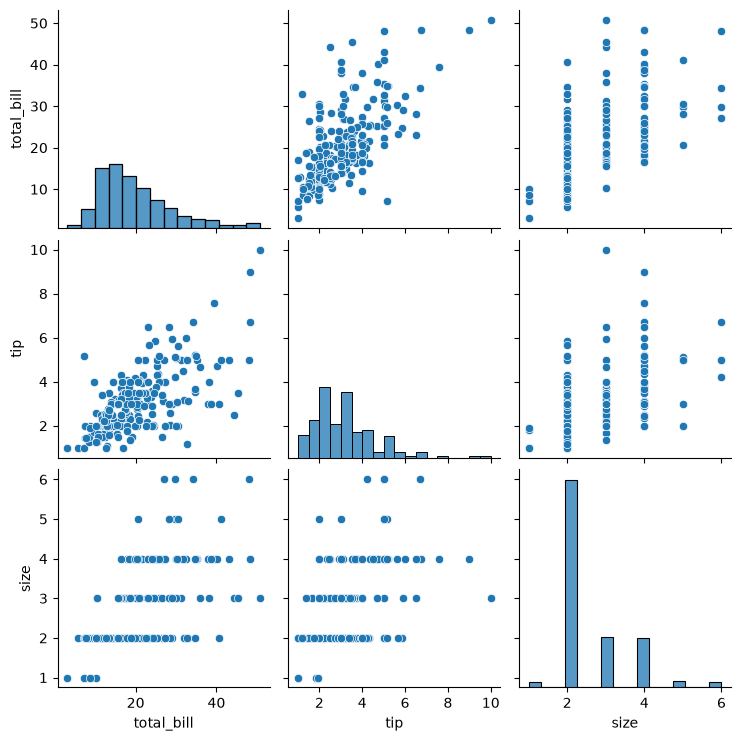

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
data=sns.load_dataset("tips")
sns.pairplot(data[['total_bill','tip','size']])
plt.show()

<Axes: ylabel='Density'>

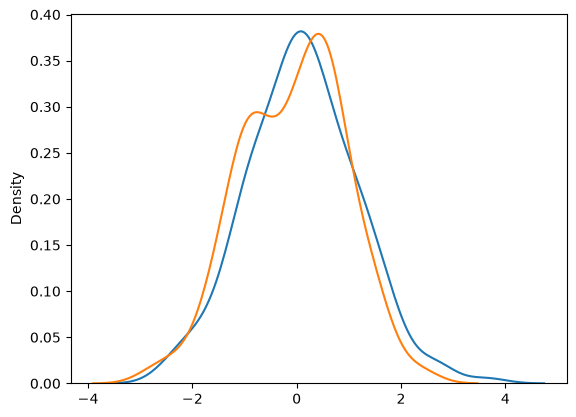

In [9]:
import seaborn as sns
import numpy as np
x=np.random.randn(200)
y=np.random.randn(200)
sns.kdeplot(x)
#kernel density
sns.kdeplot(y)

/tmp/xpython_42/1388057297.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,shade=True)


<Axes: ylabel='Density'>

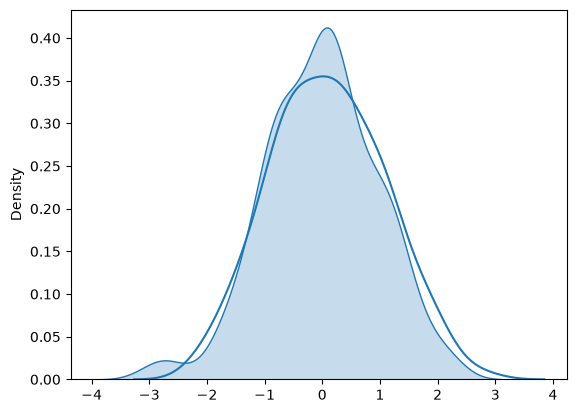

In [11]:
import seaborn as sns
import numpy as np
x=np.random.randn(200)
y=np.random.randn(200)
sns.kdeplot(x,shade=True)
sns.kdeplot(y)

/tmp/xpython_42/3167652694.py:5: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,vertical=True)


<Axes: xlabel='Density'>

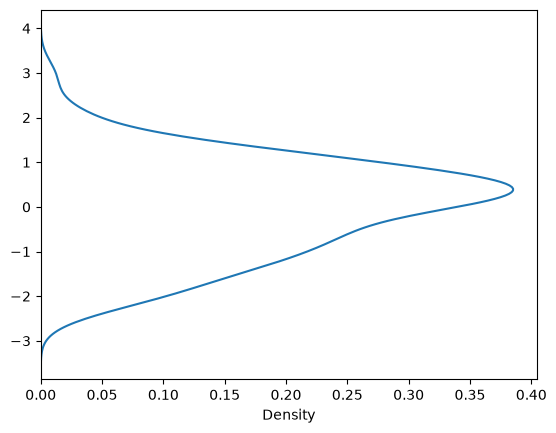

In [13]:
import seaborn as sns
import numpy as np
x=np.random.randn(200)
y=np.random.randn(200)
sns.kdeplot(x,vertical=True)


/tmp/xpython_42/1652529550.py:5: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `x`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,vertical=False)


<Axes: ylabel='Density'>

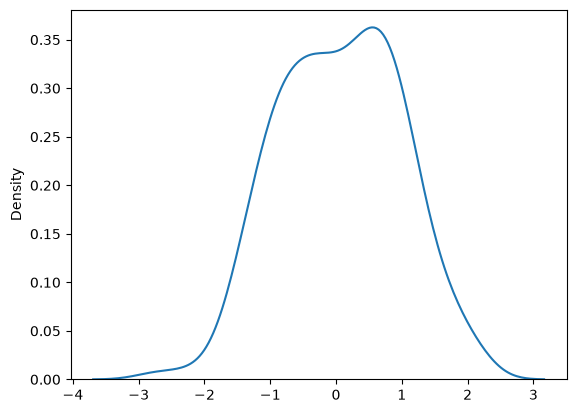

In [14]:
import seaborn as sns
import numpy as np
x=np.random.randn(200)
y=np.random.randn(200)
sns.kdeplot(x,vertical=False)

<Axes: >

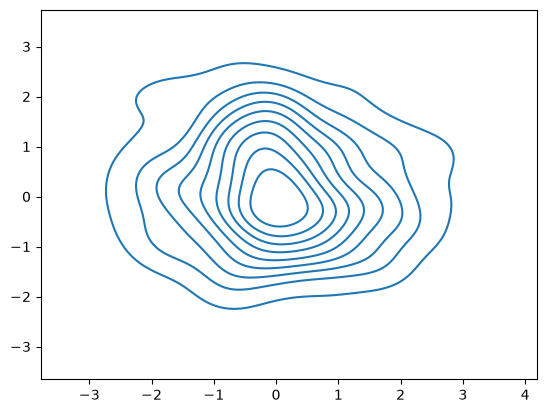

In [15]:
import seaborn as sns
import numpy as np
x=np.random.randn(200)
y=np.random.randn(200)
sns.kdeplot(x=x,y=y)

/tmp/xpython_42/1020705864.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df['petal_width'],shade=True)


<Axes: xlabel='petal_length', ylabel='Density'>

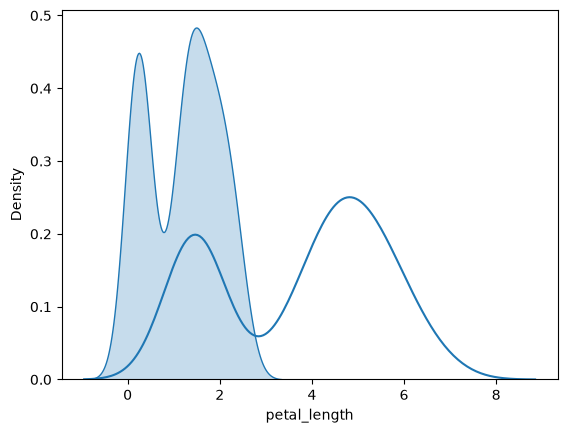

In [17]:
import seaborn as sns
df=sns.load_dataset('iris')
sns.kdeplot(x=df['petal_length'])
sns.kdeplot(x=df['petal_width'],shade=True)


<Axes: xlabel='petal_length', ylabel='petal_width'>

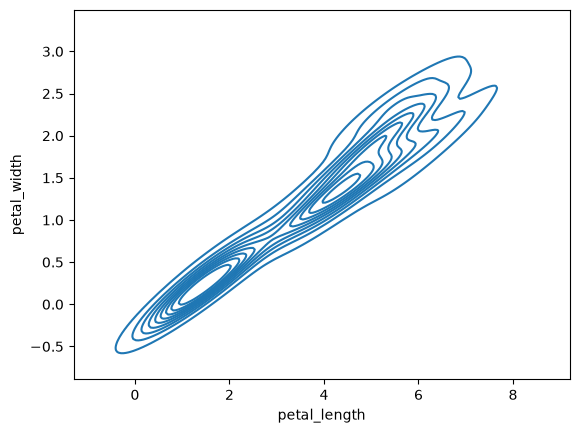

In [18]:
import seaborn as sns
df=sns.load_dataset('iris')
sns.kdeplot(x=df['petal_length'],y=df['petal_width'])

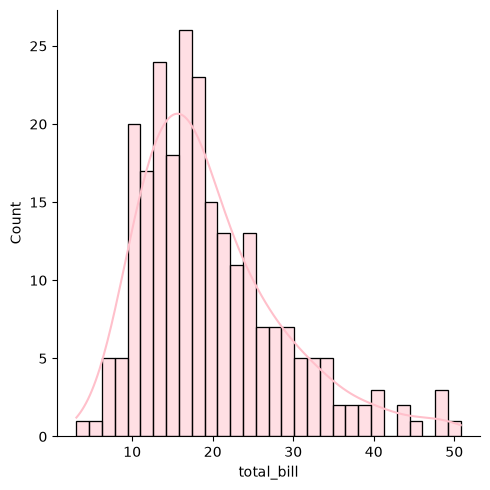

In [20]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.displot(data['total_bill'],kde=True,color='pink',bins=30)

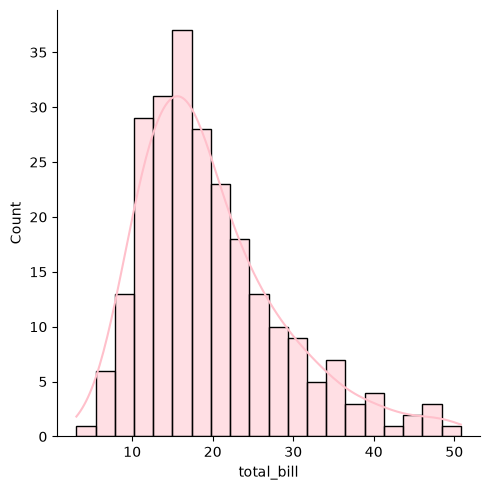

In [21]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.displot(data['total_bill'],kde=True,color='pink',bins=20)

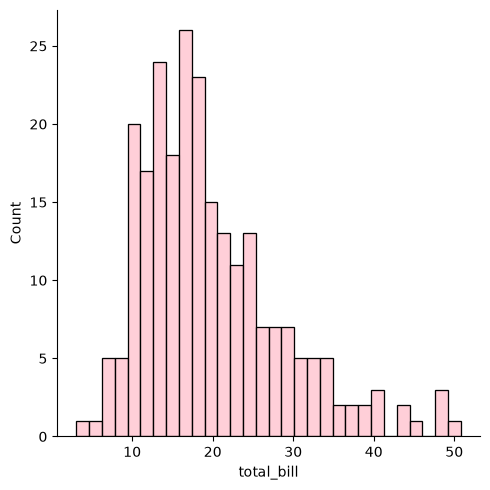

In [24]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.displot(data['total_bill'],kde=False,color='pink',bins=30)

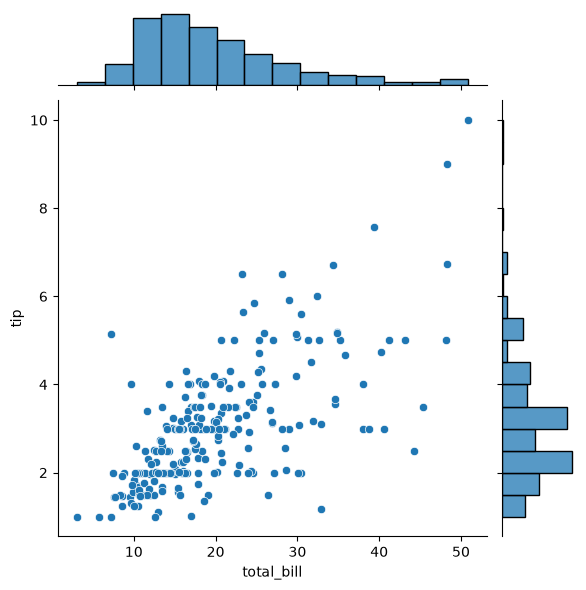

In [27]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.jointplot(x='total_bill',y='tip',data=data)

<Axes: xlabel='sex', ylabel='count'>

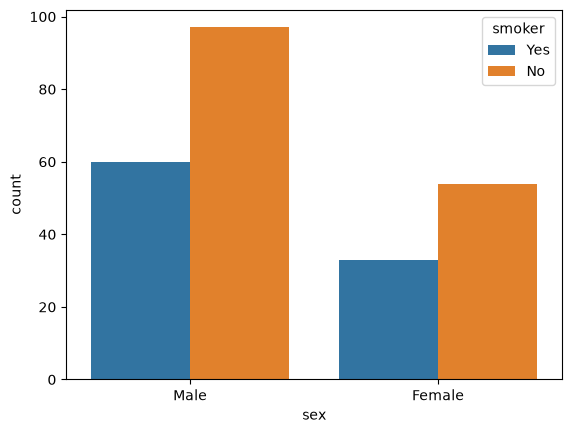

In [28]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.countplot(x='sex',hue='smoker',data=data)

<Axes: xlabel='count', ylabel='sex'>

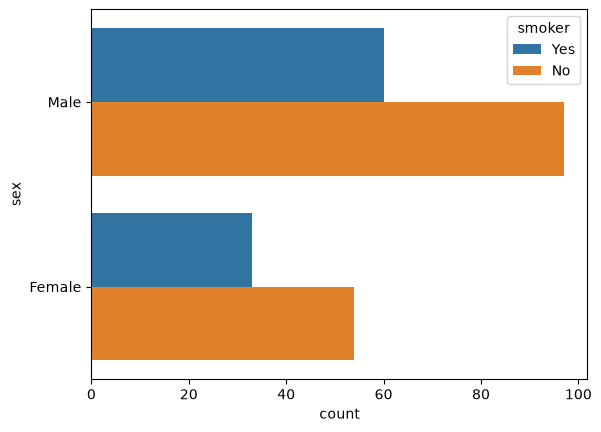

In [29]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.countplot(y='sex',hue='smoker',data=data)

<Axes: ylabel='total_bill'>

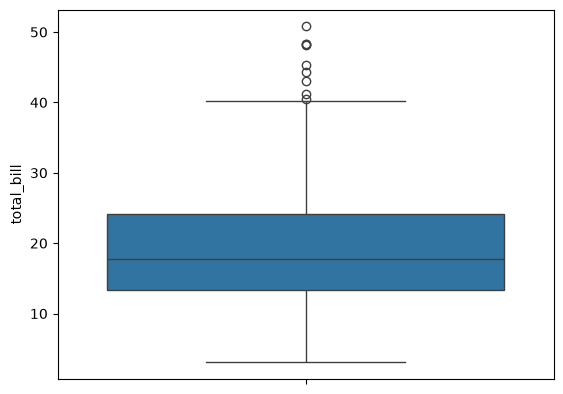

In [30]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.boxplot(data['total_bill'])

<Axes: ylabel='tip'>

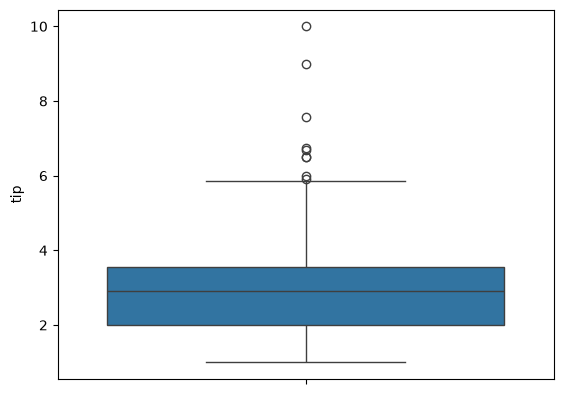

In [31]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.boxplot(data['tip'])

<Axes: ylabel='size'>

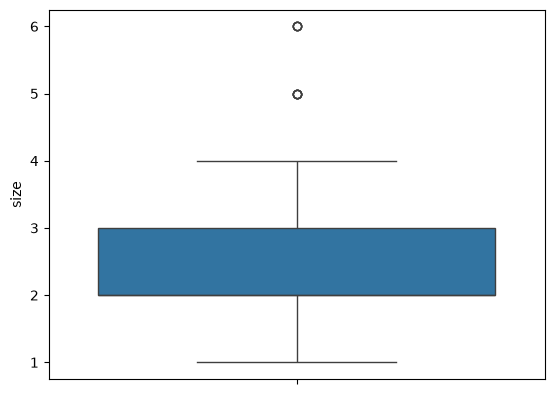

In [32]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.boxplot(data['size'])

{'whiskers': [<matplotlib.lines.Line2D at 0xd9f3a20>,
 'caps': [<matplotlib.lines.Line2D at 0xda310f8>,
 'boxes': [<matplotlib.lines.Line2D at 0xda2c8f8>],
 'medians': [<matplotlib.lines.Line2D at 0xda93b28>],
 'fliers': [<matplotlib.lines.Line2D at 0xdacebf0>],
 'means': []}

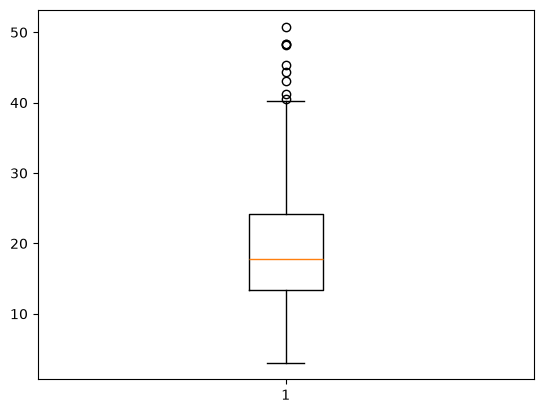

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df=pd.read_csv('tips.csv')
import numpy as np
plt.boxplot(df['total_bill'])

<Axes: ylabel='data science'>

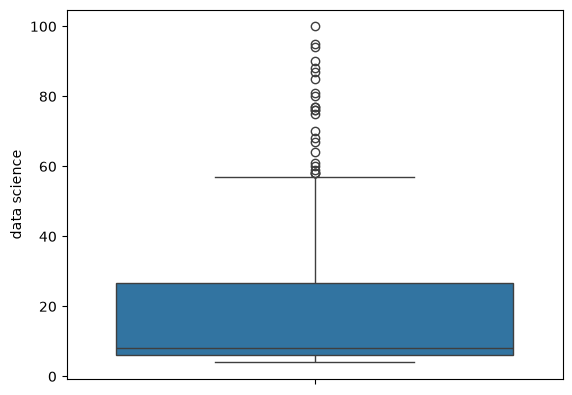

In [7]:
import seaborn as sns
import pandas as pd
df=pd.read_csv('temporal.csv')
sns.boxplot(df['data science'])

In [11]:
import seaborn as sns
import pandas as pd
import numpy as np
df=pd.read_csv('temporal.csv')
df
Q1=np.percentile(df['data science'], 25, method='midpoint')
Q3=np.percentile(df['data science'], 75, method='midpoint')
IQR=Q3-Q1
print("the out put of IQR")
print(IQR)

the out put of IQR
20.5


<Axes: >

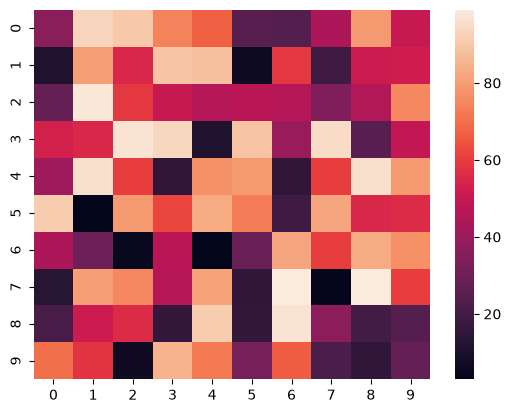

In [12]:
import seaborn as sn
import numpy as np
data=np.random.randint(1,100,(10,10))
sns.heatmap(data)

<Axes: >

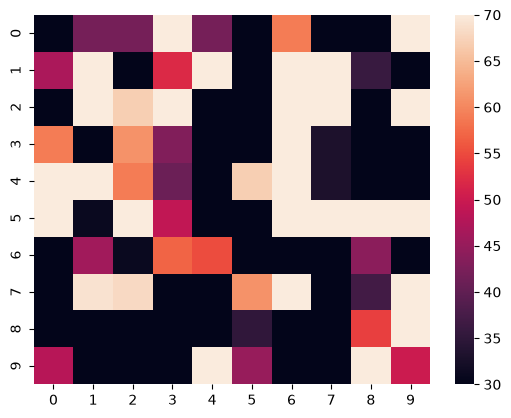

In [13]:
import seaborn as sns
import numpy as np
data=np.random.randint(1,100,(10,10))
sns.heatmap(data,vmin=30,vmax=70)

<Axes: >

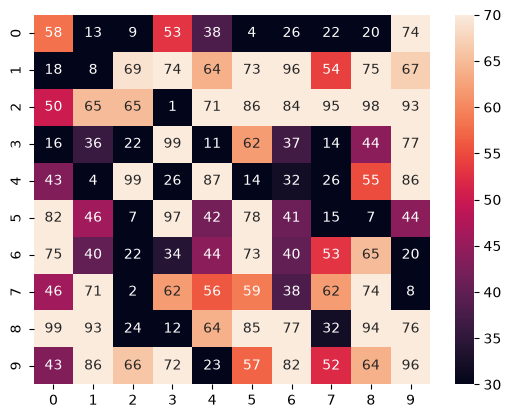

In [14]:
import seaborn as sns
import numpy as np
data=np.random.randint(1,100,(10,10))
sns.heatmap(data,vmin=30,vmax=70,annot=True)

<Axes: >

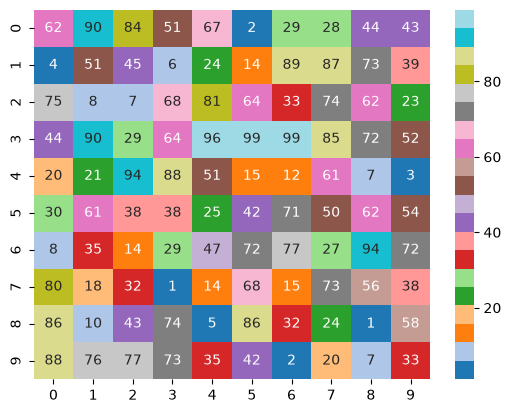

In [15]:
import seaborn as sns
import numpy as np
data=np.random.randint(1,100,(10,10))
sns.heatmap(data,cmap='tab20',annot=True)

<Axes: >

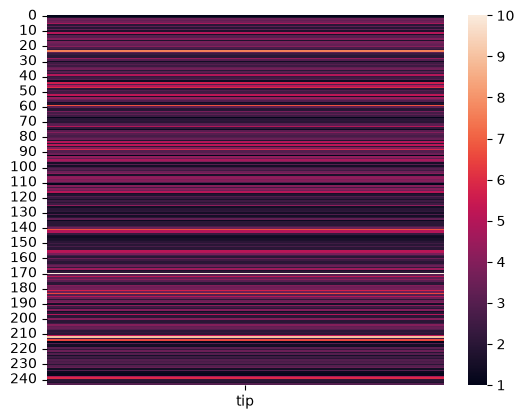

In [17]:
import seaborn as sns
data=sns.load_dataset("tips")
sns.heatmap(data[['tip']])

<Axes: >

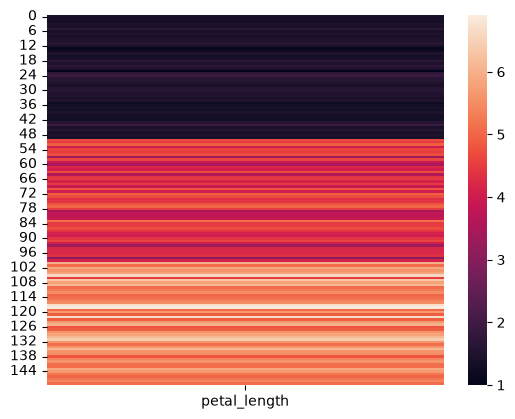

In [20]:
import seaborn as sns
data=sns.load_dataset("iris")
sns.heatmap(data[['petal_length']])

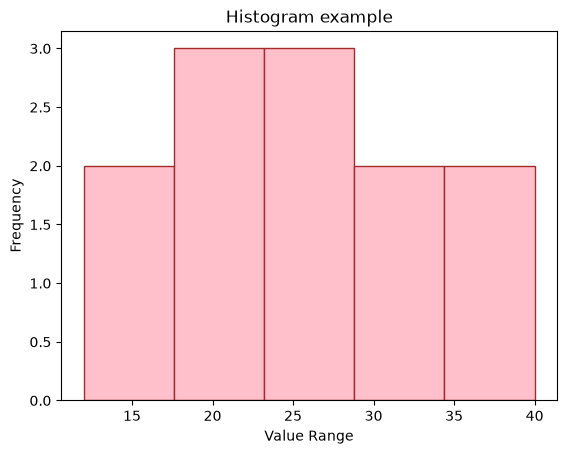

In [34]:
import matplotlib.pyplot as plt
data=[12,15,20,22,23,25,25,25,30,32,35,40]
plt.hist(data,bins=5,color='pink',edgecolor='brown')
plt.title("Histogram example")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

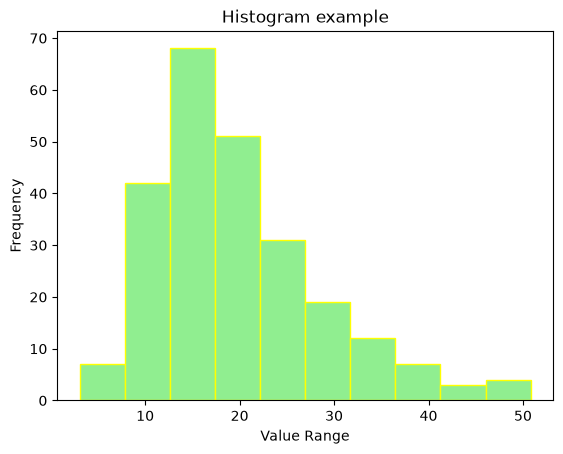

In [39]:
import seaborn as sns
data=sns.load_dataset("tips")

plt.hist(data['total_bill'],bins=10,color='lightgreen',edgecolor='yellow')
plt.title("Histogram example")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

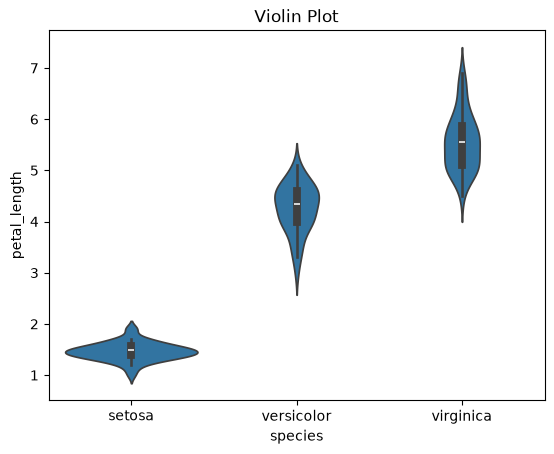

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
df=sns.load_dataset('iris')
sns.violinplot(x='species',y='petal_length',data=df)
plt.title('Violin Plot')
plt.show()

In [ ]:
!pip install dash

mambajs 0.21.4

Process pip requirements ...

Requirement jinja2 already satisfied.
Requirement markupsafe already satisfied.
Requirement packaging already satisfied.
Cannot install 'pydantic-core' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pydantic-core" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 
Requirement typing-extensions already satisfied.
Requirement comm already satisfied.


In [1]:
!mamba install pydantic-core

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pydantic-core
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.876 seconds
  Name           Version  Build            Channel
----------------------------------------------------------------
+ pydantic-core  2.48.0   py313h1e85631_0  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0     conda-forge


In [2]:
!pip install typing_extensions

mambajs 0.21.4

Process pip requirements ...



In [3]:
!pip install --upgrade pydantic

mambajs 0.21.4

Process pip requirements ...

Requirement pydantic-core already satisfied.
Requirement typing-extensions already satisfied.


In [5]:
!mamba install pydantic

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pydantic-core, pydantic
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.160 seconds
  Name               Version            Build                 Channel
-----------------------------------------------------------------------------------
~ pydantic           2.13.5 -> 1.10.22  none -> pyh3cfb1c2_0  PyPi -> conda-forge
~ typing_extensions  4.16.0 -> 4.15.0   none -> pyhcf101f3_0  PyPi -> conda-forge


In [6]:
import dash
from dash import dcc,html
app= dash.Dash(__name__)
app.layout=html.Div([
    html.H1("Dash Tutorial"),
    dcc.Graph(
        id="example",
        figure={
            "data": [
                {
                    "x":[1,2,3,4,5],
                    "y":[5,4,7,4,8],
                    "type":"line",
                    "name":"Trucks"
                },
                {
                    "x":[1,2,3,4,5],
                    "y":[6,3,5,3,7],
                    "type":"bar",
                    "name":"Ships"

                }
            ],
    "layout": {
                    "title":"Basic Dashboard"
    }
        }
    )
])
app.run(debug=True,port=8052)

<class 'ImportError'>: cannot import name 'compiled' from 'pydantic.version' (/lib/python3.13/site-packages/pydantic/version.py)